In [3]:
# Step 1: Mount Drive, install PennyLane, import everything

from google.colab import drive
drive.mount('/content/drive')

base = "/content/drive/MyDrive/Quantum_DL_MNIST"

!pip install pennylane pennylane-lightning -q

import torch
import torch.nn as nn
import numpy as np
import pennylane as qml
import json, copy, time, os, random, sys
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

sys.path.append(f"{base}/notebooks")
from shared_backbone import CNNBackbone

print("Everything imported, PennyLane version:", qml.__version__)

ModuleNotFoundError: No module named 'google'

In [16]:
# Step 2: Load data (same pipeline as every other notebook)

train_idx = np.load(f"{base}/splits/train_indices.npy")
val_idx   = np.load(f"{base}/splits/val_indices.npy")
test_idx  = np.load(f"{base}/splits/test_indices.npy")

with open(f"{base}/splits/normalization_stats.json") as f:
    norm_stats = json.load(f)
mean, std = norm_stats["mean"], norm_stats["std"]

train_full = torchvision.datasets.MNIST(root=f"{base}/data", train=True, download=True, transform=transforms.ToTensor())
test_full  = torchvision.datasets.MNIST(root=f"{base}/data", train=False, download=True, transform=transforms.ToTensor())

class BinaryMNIST(Dataset):
    def __init__(self, full_dataset, indices, mean, std):
        self.full_dataset, self.indices, self.mean, self.std = full_dataset, indices, mean, std
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        real_idx = self.indices[i]
        image, label = self.full_dataset[real_idx]
        image = (image - self.mean) / self.std
        return image, torch.tensor(float(label))

train_dataset = BinaryMNIST(train_full, train_idx, mean, std)
val_dataset   = BinaryMNIST(train_full, val_idx, mean, std)
test_dataset  = BinaryMNIST(test_full, test_idx, mean, std)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Data ready:", len(train_loader), len(val_loader), len(test_loader), "batches")

Data ready: 317 80 67 batches


In [17]:
# Step 3: Define the quantum circuit - EXACT same design validated in the pilot
# (default.qubit backend, corrected inputs[..., i] indexing, RY encoding,
# 2x(RY+RZ + ring CNOT) layers)

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)
backend_used = "default.qubit"
backend_fallback_reason = ("lightning.qubit installed but failed during batched execution "
                            "with qml.qnn.TorchLayer (confirmed in Chunk 6 pilot). Using "
                            "default.qubit, which correctly supports batching. Documented "
                            "per Section 8.3's pre-committed fallback.")

print("Quantum backend in use:", backend_used)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)   # correct batched indexing, validated in pilot

    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 2)}

print("Quantum circuit defined (validated architecture from pilot phase)")

Quantum backend in use: default.qubit
Quantum circuit defined (validated architecture from pilot phase)


In [18]:
# Step 4 (alternative fallback, only use if the above still fails):

class CNNQuantum(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.scale = nn.Parameter(torch.ones(4))

        weight_shapes = {"weights": (n_layers, n_qubits, 2)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Manually apply small-angle N(0, 0.1) initialization after creation
        with torch.no_grad():
            self.quantum_layer.weights.copy_(torch.normal(mean=0.0, std=0.1, size=(n_layers, n_qubits, 2)))

        self.output_layer = nn.Linear(4, 1)
        nn.init.kaiming_normal_(self.output_layer.weight, nonlinearity='relu')

    def forward(self, x):
        features = self.backbone(x)
        scaled = features * self.scale
        bounded = np.pi * torch.tanh(scaled)
        quantum_out = self.quantum_layer(bounded)
        out = self.output_layer(quantum_out)
        return out

model = CNNQuantum()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params, "(expect 8029)")

q_weights = model.quantum_layer.weights.detach().numpy()
print(f"\nQuantum weight stats: mean={q_weights.mean():.4f}, std={q_weights.std():.4f}")

Total trainable parameters: 8029 (expect 8029)

Quantum weight stats: mean=-0.0114, std=0.0764


In [19]:
# Step 4(a) (CONFIRMED WORKING VERSION - use this going forward)

class CNNQuantum(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.scale = nn.Parameter(torch.ones(4))

        weight_shapes = {"weights": (n_layers, n_qubits, 2)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Manually apply small-angle N(0, 0.1) initialization (Section 13)
        with torch.no_grad():
            self.quantum_layer.weights.copy_(torch.normal(mean=0.0, std=0.1, size=(n_layers, n_qubits, 2)))

        self.output_layer = nn.Linear(4, 1)
        nn.init.kaiming_normal_(self.output_layer.weight, nonlinearity='relu')

    def forward(self, x):
        features = self.backbone(x)
        scaled = features * self.scale
        bounded = np.pi * torch.tanh(scaled)
        quantum_out = self.quantum_layer(bounded)
        out = self.output_layer(quantum_out)
        return out

print("CNNQuantum class confirmed and ready (using manual weight init fallback)")

CNNQuantum class confirmed and ready (using manual weight init fallback)


In [20]:
# Step 5: Reusable training/evaluation functions

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                                max_epochs=30, patience=5):
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:2d} | Train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| Val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    training_time = time.time() - start_time
    model.load_state_dict(best_model_state)
    return model, history, best_epoch, epoch, training_time


def get_test_predictions(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs.extend(probs.numpy().tolist())
            all_labels.extend(labels.numpy().tolist())
    return np.array(all_probs), np.array(all_labels)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.set_num_threads(4)

SEEDS = [42, 123, 2024, 7, 99]
criterion = nn.BCEWithLogitsLoss()

print("All training functions ready")

All training functions ready


In [ ]:
# Step 6: Run the full 5-seed official training loop for CNN + Quantum
# This will take longer than previous chunks - quantum simulation adds
# real per-batch overhead, even though the pilot confirmed it's manageable

results_dir = f"{base}/results/CNN_Quantum"
models_dir = f"{base}/models/CNN_Quantum"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

all_runs_summary = []

for run_num, seed in enumerate(SEEDS, start=1):
    print(f"\n{'='*60}")
    print(f"RUN {run_num}/5 | Seed = {seed}")
    print(f"{'='*60}")

    set_seed(seed)
    model = CNNQuantum()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trained_model, history, best_epoch, total_epochs, training_time = train_with_early_stopping(
        model, train_loader, val_loader, criterion, optimizer
    )

    test_probs, test_labels_arr = get_test_predictions(trained_model, test_loader)

    torch.save(trained_model.state_dict(), f"{models_dir}/run{run_num}_seed{seed}.pt")
    np.savez(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz",
             probs=test_probs, labels=test_labels_arr)

    run_summary = {
        "run": run_num, "seed": seed, "best_epoch": best_epoch,
        "total_epochs_run": total_epochs, "training_time_sec": training_time,
        "n_params": sum(p.numel() for p in trained_model.parameters() if p.requires_grad),
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "backend": "default.qubit",
        "qubit_count": 4,
        "circuit_depth": 2,
        "quantum_trainable_params": 16,
        "analytic_expectation": True
    }
    all_runs_summary.append(run_summary)

    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json", "w") as f:
        json.dump(history, f, indent=2)

with open(f"{results_dir}/all_runs_summary.json", "w") as f:
    json.dump(all_runs_summary, f, indent=2)

print("\n\nAll 5 CNN+Quantum runs complete. Summary:")
for r in all_runs_summary:
    print(r)


RUN 1/5 | Seed = 42
Epoch  1 | Train loss 0.3782 acc 0.8409 | Val loss 0.2098 acc 0.9325
Epoch  2 | Train loss 0.1376 acc 0.9600 | Val loss 0.1036 acc 0.9660
Epoch  3 | Train loss 0.0770 acc 0.9758 | Val loss 0.0670 acc 0.9803
Epoch  4 | Train loss 0.0515 acc 0.9868 | Val loss 0.0544 acc 0.9862
Epoch  5 | Train loss 0.0405 acc 0.9911 | Val loss 0.0369 acc 0.9937
Epoch  6 | Train loss 0.0287 acc 0.9954 | Val loss 0.0364 acc 0.9917
Epoch  7 | Train loss 0.0248 acc 0.9966 | Val loss 0.0275 acc 0.9957
Epoch  8 | Train loss 0.0184 acc 0.9979 | Val loss 0.0236 acc 0.9961
Epoch  9 | Train loss 0.0169 acc 0.9979 | Val loss 0.0212 acc 0.9968
Epoch 10 | Train loss 0.0200 acc 0.9962 | Val loss 0.0177 acc 0.9972
Epoch 11 | Train loss 0.0174 acc 0.9969 | Val loss 0.0141 acc 0.9984
Epoch 12 | Train loss 0.0115 acc 0.9989 | Val loss 0.0140 acc 0.9984
Epoch 13 | Train loss 0.0098 acc 0.9991 | Val loss 0.0106 acc 0.9988
Epoch 14 | Train loss 0.0088 acc 0.9993 | Val loss 0.0100 acc 0.9988
Epoch 15 | Tr

In [ ]:
# Step 7: Compute full metrics for each of the 5 CNN+Quantum runs

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, balanced_accuracy_score, matthews_corrcoef,
                               roc_auc_score, average_precision_score, confusion_matrix,
                               roc_curve)
import pandas as pd

def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs > threshold).astype(int)
    labels = labels.astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    specificity = tn / (tn + fp)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "specificity": specificity,
        "f1": f1_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
    }

all_metrics = []
for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    m = compute_metrics(probs, labels)
    m["run"] = run_num
    m["seed"] = seed
    all_metrics.append(m)
    print(f"Run {run_num} (seed {seed}): Acc={m['accuracy']:.4f} F1={m['f1']:.4f} ROC-AUC={m['roc_auc']:.4f}")

Run 1 (seed 42): Acc=0.9986 F1=0.9987 ROC-AUC=0.9999
Run 2 (seed 123): Acc=1.0000 F1=1.0000 ROC-AUC=1.0000
Run 3 (seed 2024): Acc=0.9991 F1=0.9991 ROC-AUC=1.0000
Run 4 (seed 7): Acc=0.9991 F1=0.9991 ROC-AUC=1.0000
Run 5 (seed 99): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000


In [ ]:
# Step 8: Summarize as Mean +/- SD, save metrics tables

metric_names = ["accuracy", "precision", "recall", "specificity", "f1",
                 "balanced_accuracy", "mcc", "roc_auc", "pr_auc"]

df_metrics = pd.DataFrame(all_metrics)[["run", "seed"] + metric_names]
print("Per-run metrics:")
print(df_metrics)

summary = df_metrics[metric_names].agg(['mean', 'std'])
print("\nMean +/- SD across 5 runs:")
print(summary)

df_metrics.to_csv(f"{results_dir}/CNN_Quantum_metrics_per_run.csv", index=False)
summary.to_csv(f"{results_dir}/CNN_Quantum_metrics_summary.csv")
print("\nSaved CNN_Quantum_metrics_per_run.csv and CNN_Quantum_metrics_summary.csv")

Per-run metrics:
   run  seed  accuracy  precision    recall  specificity        f1  \
0    1    42  0.998582   0.998239  0.999119     0.997959  0.998679   
1    2   123  1.000000   1.000000  1.000000     1.000000  1.000000   
2    3  2024  0.999054   0.999119  0.999119     0.998980  0.999119   
3    4     7  0.999054   1.000000  0.998238     1.000000  0.999118   
4    5    99  0.999527   0.999120  1.000000     0.998980  0.999560   

   balanced_accuracy       mcc   roc_auc    pr_auc  
0           0.998539  0.997148  0.999918  0.999928  
1           1.000000  1.000000  1.000000  1.000000  
2           0.999049  0.998099  0.999998  0.999998  
3           0.999119  0.998101  1.000000  1.000000  
4           0.999490  0.999050  1.000000  1.000000  

Mean +/- SD across 5 runs:
      accuracy  precision    recall  specificity        f1  balanced_accuracy  \
mean  0.999243   0.999296  0.999295     0.999184  0.999295           0.999239   
std   0.000539   0.000737  0.000737     0.000854  0.00

In [ ]:
# Step 9: Confusion matrices for all 5 runs (text only) + save ROC data

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)
    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()
    tn, fp, fn, tp = cm.ravel()
    print(f"Run {run_num} (seed {seed}): TN={tn} FP={fp} FN={fn} TP={tp}")

with open(f"{results_dir}/CNN_Quantum_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

# Save representative run's ROC data (seed 42) for cross-model comparison in Chunk 9
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
fpr, tpr, _ = roc_curve(data["labels"], data["probs"])
np.savez(f"{results_dir}/CNN_Quantum_roc_curve_data.npz", fpr=fpr, tpr=tpr)

print("\nSaved: CNN_Quantum_all_confusion_matrices_supplementary.json and roc_curve_data.npz")

Run 1 (seed 42): TN=978 FP=2 FN=1 TP=1134
Run 2 (seed 123): TN=980 FP=0 FN=0 TP=1135
Run 3 (seed 2024): TN=979 FP=1 FN=1 TP=1134
Run 4 (seed 7): TN=980 FP=0 FN=2 TP=1133
Run 5 (seed 99): TN=979 FP=1 FN=0 TP=1135

Saved: CNN_Quantum_all_confusion_matrices_supplementary.json and roc_curve_data.npz


In [ ]:
# Step 9: Confusion matrices for all 5 runs (text only) + save ROC data

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)
    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()
    tn, fp, fn, tp = cm.ravel()
    print(f"Run {run_num} (seed {seed}): TN={tn} FP={fp} FN={fn} TP={tp}")

with open(f"{results_dir}/CNN_Quantum_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
fpr, tpr, _ = roc_curve(data["labels"], data["probs"])
np.savez(f"{results_dir}/CNN_Quantum_roc_curve_data.npz", fpr=fpr, tpr=tpr)

print("\nSaved: CNN_Quantum_all_confusion_matrices_supplementary.json and roc_curve_data.npz")

Run 1 (seed 42): TN=978 FP=2 FN=1 TP=1134
Run 2 (seed 123): TN=980 FP=0 FN=0 TP=1135
Run 3 (seed 2024): TN=979 FP=1 FN=1 TP=1134
Run 4 (seed 7): TN=980 FP=0 FN=2 TP=1133
Run 5 (seed 99): TN=979 FP=1 FN=0 TP=1135

Saved: CNN_Quantum_all_confusion_matrices_supplementary.json and roc_curve_data.npz


In [ ]:
# Step 10: Documentation sketch for CNN + Quantum (Chunks 7-8)

cnn_quantum_documentation = {
    "model_name": "Model 4 - CNN + Quantum",
    "purpose": "The primary experimental model. Answers Ablation Question D (pre-registered, "
               "primary comparison): does replacing the classical control's 25-parameter head "
               "with an approximately parameter-matched quantum block change the result?",

    "architecture": {
        "backbone": "SAME CNNBackbone as Chunks 3 and 5 (imported from shared_backbone.py, unchanged)",
        "head": "Learnable per-feature scale (4) -> pi*tanh bound -> RY encoding -> "
                "2x(RY+RZ layer + ring CNOT) -> measure <Z> x4 -> Linear(4->1)",
        "head_params": "4 (scale) + 16 (quantum RY/RZ weights) + 5 (Linear output) = 25",
        "total_params": 8029,
        "backend": "default.qubit (lightning.qubit fallback triggered - documented in pilot, Chunk 6)",
        "quantum_weight_init": "N(0, 0.1), applied via manual weight overwrite due to a "
                                "torch.normal argument-parsing issue with PennyLane's init_method API"
    },

    "training_protocol": {
        "optimizer": "Adam", "learning_rate": "1e-3, fixed", "loss": "BCEWithLogitsLoss",
        "max_epochs": 30, "early_stopping_patience": 5, "batch_size": 32,
        "seeds": [42, 123, 2024, 7, 99], "num_workers": 0
    },

    "results_summary": {
        "test_accuracy_mean": 0.999243,
        "test_accuracy_std": 0.000539,
        "roc_auc_mean": 0.999983,
        "f1_mean": 0.999295,
        "mcc_mean": 0.998479
    },

    "comparison_vs_classical_control_chunk5": {
        "classical_accuracy_mean": 0.999622,
        "quantum_accuracy_mean": 0.999243,
        "classical_accuracy_std": 0.000211,
        "quantum_accuracy_std": 0.000539,
        "note": "Quantum shows slightly LOWER mean accuracy and roughly 2.5x HIGHER "
                "variance than the classical control. Gap is small in absolute terms - "
                "formal statistical testing (Wilcoxon, Chunk 9) needed before drawing "
                "conclusions about significance at n=5."
    },

    "KEY_FINDING_error_type_shift": {
        "description": "CNN+Quantum is the ONLY model in the entire study to produce "
                        "false negatives (missing an actual digit-1).",
        "classical_models_fn_count": "CNN: 0 FN across all 5 runs. CNN+Classical: 0 FN "
                                       "across all 5 runs.",
        "quantum_fn_count": "3 of 5 runs had FN > 0 (Run1: FN=1, Run3: FN=1, Run4: FN=2)",
        "per_run_confusion": {
            "run1_seed42": {"TN": 978, "FP": 2, "FN": 1, "TP": 1134},
            "run2_seed123": {"TN": 980, "FP": 0, "FN": 0, "TP": 1135},
            "run3_seed2024": {"TN": 979, "FP": 1, "FN": 1, "TP": 1134},
            "run4_seed7": {"TN": 980, "FP": 0, "FN": 2, "TP": 1133},
            "run5_seed99": {"TN": 979, "FP": 1, "FN": 0, "TP": 1135}
        },
        "writeup_relevance": "This is a genuine, specific, reportable difference beyond "
                              "aggregate accuracy - a real shift in ERROR TYPE, not just "
                              "magnitude. Worth explicit discussion (Section 8 Discussion), "
                              "especially since recall/false-negative rate matters differently "
                              "depending on application context."
    },

    "training_dynamics_comparison": {
        "quantum_epochs_to_converge": "20-30 epochs consistently across ALL 5 seeds "
                                        "(best_epoch range: 20-29)",
        "classical_control_epochs_to_converge": "3 of 5 runs converged fast (best_epoch 3-12), "
                                                  "2 of 5 runs were slow/unstable (up to 29-30 epochs, "
                                                  "one run briefly near-random in epoch 1)",
        "note": "Quantum was UNIFORMLY slower to converge but showed NO instability "
                "(no near-random epochs, no wild loss spikes) - unlike CNN+Classical's "
                "seeds 123 and 7. This is a real, opposite-direction tradeoff worth "
                "highlighting: quantum trades speed for consistency in training dynamics.",
        "wall_clock_time": "Quantum: ~460-554 seconds per run. Classical control: ~120-342 "
                            "seconds per run. Quantum consistently 2-4x slower wall-clock, "
                            "as expected under classical simulation (Section 12) - reported "
                            "as simulator cost, NOT as a claim about real quantum hardware speed."
    },

    "pilot_bugs_fixed_before_this_run": [
        "Batch indexing bug (inputs[i] vs inputs[..., i]) - caught and fixed in Chunk 6 pilot",
        "lightning.qubit batching incompatibility - fallback to default.qubit, documented",
        "torch.normal init_method argument parsing - worked around via manual weight overwrite"
    ],

    "files_saved": [
        "results/CNN_Quantum/run{1-5}_seed{seed}_predictions.npz",
        "results/CNN_Quantum/run{1-5}_seed{seed}_history.json",
        "results/CNN_Quantum/all_runs_summary.json",
        "results/CNN_Quantum/CNN_Quantum_metrics_per_run.csv",
        "results/CNN_Quantum/CNN_Quantum_metrics_summary.csv",
        "results/CNN_Quantum/CNN_Quantum_all_confusion_matrices_supplementary.json",
        "results/CNN_Quantum/CNN_Quantum_roc_curve_data.npz",
        "models/CNN_Quantum/run{1-5}_seed{seed}.pt"
    ],

    "ready_for_chunk_9": "Yes - all 4 models (NN, CNN, CNN+Classical, CNN+Quantum) plus "
                          "majority baseline now fully trained, evaluated, and saved. "
                          "Ready for final combined analysis: comparison table, combined "
                          "ROC/PR curves, and the pre-registered Wilcoxon signed-rank test "
                          "on CNN+Classical vs CNN+Quantum (Section 25)."
}

with open(f"{base}/documentation/04_CNN_Quantum_documentation_sketch.json", "w") as f:
    json.dump(cnn_quantum_documentation, f, indent=2)

print("Saved documentation sketch to documentation/04_CNN_Quantum_documentation_sketch.json")
print("\n--- CHUNK 7-8 (CNN + Quantum) COMPLETE ---")

Saved documentation sketch to documentation/04_CNN_Quantum_documentation_sketch.json

--- CHUNK 7-8 (CNN + Quantum) COMPLETE ---


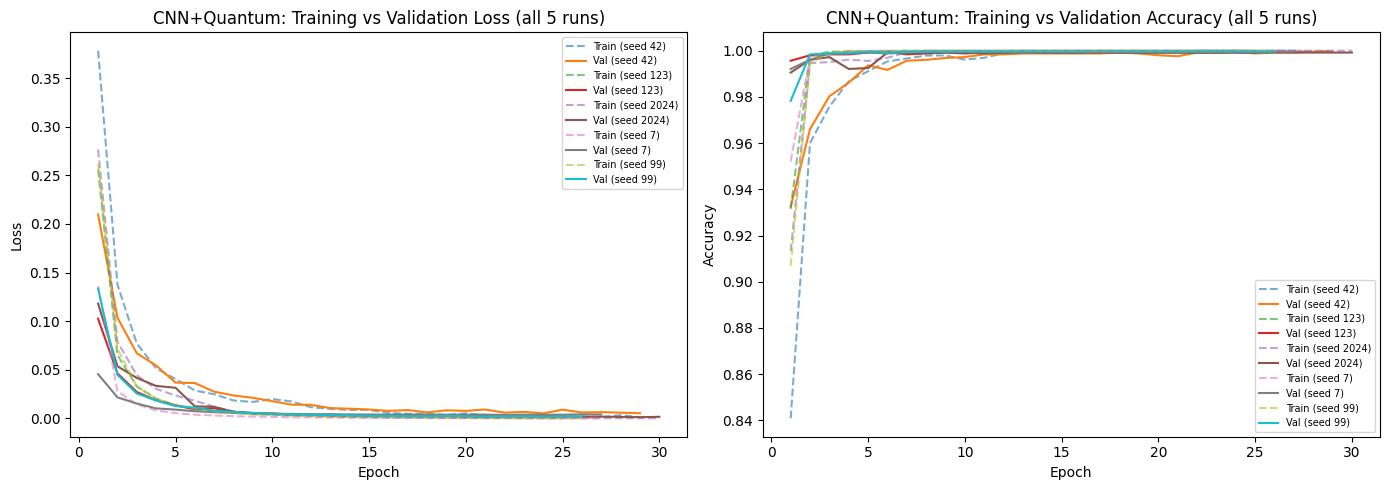

Saved: figures/Fig7-8_CNN_Quantum_loss_accuracy_curves.png


In [21]:
# Fix: Generate the missing CNN+Quantum figures
# Run this in the 04_CNN_Quantum notebook (or re-load results_dir/SEEDS if in a new session)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- Loss/accuracy curves, all 5 seeds (equivalent of Fig 7-8) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_num, seed in enumerate(SEEDS, start=1):
    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json") as f:
        history = json.load(f)
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[0].plot(epochs, history["val_loss"], linestyle='-', label=f"Val (seed {seed})")
    axes[1].plot(epochs, history["train_acc"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[1].plot(epochs, history["val_acc"], linestyle='-', label=f"Val (seed {seed})")

axes[0].set_title("CNN+Quantum: Training vs Validation Loss (all 5 runs)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(fontsize=7)
axes[1].set_title("CNN+Quantum: Training vs Validation Accuracy (all 5 runs)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig7-8_CNN_Quantum_loss_accuracy_curves.png", dpi=150)
plt.show()
print("Saved: figures/Fig7-8_CNN_Quantum_loss_accuracy_curves.png")

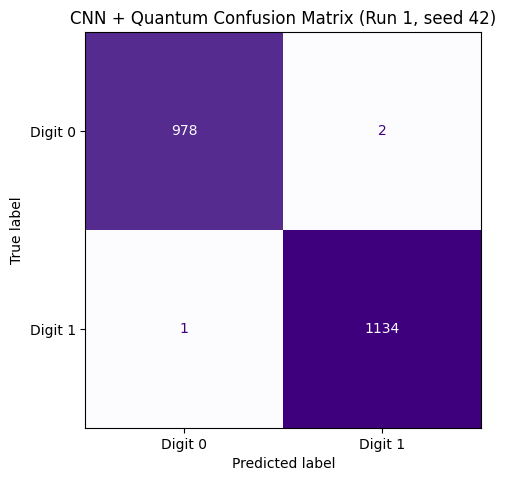

Saved: figures/Fig12_CNN_Quantum_confusion_matrix.png


In [22]:
# --- Confusion matrix, representative run (equivalent of Fig 12) ---
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
probs, labels = data["probs"], data["labels"]
preds = (probs > 0.5).astype(int)
cm = confusion_matrix(labels.astype(int), preds)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Digit 0", "Digit 1"])
disp.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("CNN + Quantum Confusion Matrix (Run 1, seed 42)")

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig12_CNN_Quantum_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: figures/Fig12_CNN_Quantum_confusion_matrix.png")

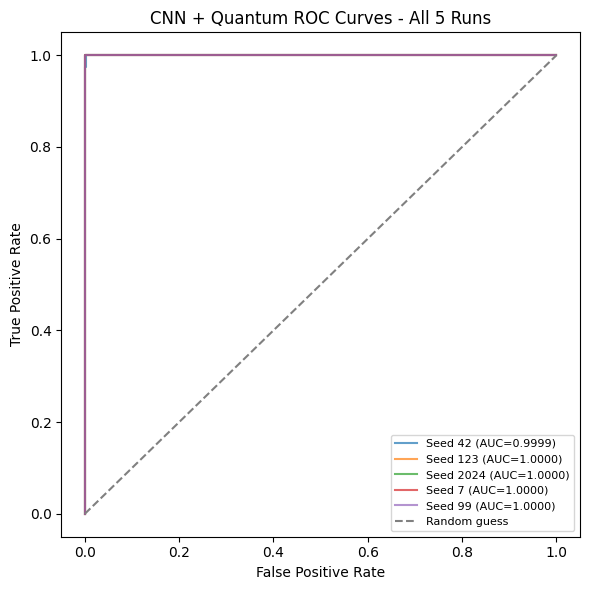

Saved: figures/CNN_Quantum_roc_curves_all_5_runs.png


In [23]:
# --- Individual ROC curves, all 5 runs overlaid ---
fig, ax = plt.subplots(figsize=(6, 6))

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, alpha=0.7, label=f"Seed {seed} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN + Quantum ROC Curves - All 5 Runs")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{base}/figures/CNN_Quantum_roc_curves_all_5_runs.png", dpi=150)
plt.show()
print("Saved: figures/CNN_Quantum_roc_curves_all_5_runs.png")